# Función de clasificación de tweets nuevos

**CC3084 · Ciencia de Datos · Universidad del Valle de Guatemala · Semestre II, 2026**

Este cuaderno cubre el **ejercicio 7**. El requisito es literal: una función que *"recibe el
texto de un tweet **sin preprocesar** y devuelve si se refiere a un desastre natural o no"*.

La función vive en `src/clasificador.py`, no en una celda de este cuaderno. La diferencia no
es cosmética: un cuaderno no se puede importar desde otro programa, así que una función que
solo existe dentro de él no es utilizable. Que esté en un módulo es lo que demuestra que
funciona de verdad, y este cuaderno lo comprueba ejecutándola **en un intérprete separado**
que no ha corrido ninguna celda previa.

```python
clasificar_tweet(texto)  ->  {'texto_original', 'texto_procesado', 'prediccion',
                              'confianza', 'sentimiento', 'advertencia'}
```

El plan del cuaderno:

1. Comprobar que la función corre en un intérprete limpio.
2. Clasificar **12 tweets escritos por el equipo**: 4 claramente de desastre, 4 claramente
   no, y 4 diseñados para engañar al modelo.
3. Descomponer cada error en las palabras que lo causaron.
4. Comprobar el manejo de los casos borde.

In [1]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ / 'src'))

import config
from clasificador import clasificar_tweet, clasificar_tweets, cargar_modelo

config.asegurar_directorios()

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = config.FIG_DPI
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 70)


def guardar(fig, nombre):
    fig.savefig(config.FIGURES / nombre)
    print(f'figura guardada: results/figures/{nombre}')


def guardar_tabla(df, nombre):
    df.to_csv(config.TABLES / nombre, index=False)
    print(f'tabla guardada: results/tables/{nombre}  ({len(df)} filas)')


resultado = clasificar_tweet(
    'Massive earthquake just hit downtown, several buildings collapsed')
for clave, valor in resultado.items():
    print(f'{clave:16s} {valor}')

texto_original   Massive earthquake just hit downtown, several buildings collapsed
texto_procesado  massive earthquake hit downtown several building collapsed
prediccion       desastre
confianza        0.7998
sentimiento      negativo
advertencia      None


## Primero: ¿funciona fuera de este cuaderno?

La afirmación *"la función es importable y no depende de que se haya ejecutado un cuaderno"*
es fácil de escribir y fácil de incumplir sin darse cuenta, porque dentro de un cuaderno ya
hay variables en memoria que la disimulan.

La celda siguiente lanza un **proceso de Python completamente nuevo**, que no ha ejecutado
ninguna celda de este cuaderno ni de ningún otro, importa el módulo y clasifica un tweet. Si
la función dependiera de algún estado previo, aquí fallaría.

In [2]:
programa = (
    "import sys; sys.path.insert(0, 'src')\n"
    "from clasificador import clasificar_tweet\n"
    "r = clasificar_tweet('Wildfire is spreading fast, evacuate the area now')\n"
    "print(r['prediccion'], round(r['confianza'], 4), '|', r['texto_procesado'])\n"
)

proceso = subprocess.run([sys.executable, '-c', programa], cwd=str(RAIZ),
                         capture_output=True, text=True, encoding='utf-8')

print('código de salida:', proceso.returncode)
print('salida:', proceso.stdout.strip())
if proceso.stderr.strip():
    print('errores:', proceso.stderr.strip()[-400:])

assert proceso.returncode == 0, 'La función no corre en un intérprete limpio.'
print()
print('Verificado: el módulo se importa y clasifica sin haber ejecutado ningún cuaderno.')

código de salida: 0
salida: desastre 0.8148 | wildfire spreading fast evacuate area

Verificado: el módulo se importa y clasifica sin haber ejecutado ningún cuaderno.


## Los 12 tweets del equipo

Ninguno viene del conjunto de datos. Están escritos a propósito para poner a prueba tres
cosas distintas:

- **Cuatro claramente de desastre.** Redactados como los redactaría un medio o un testigo,
  con el vocabulario que el modelo debería reconocer.
- **Cuatro claramente ajenos.** Vida cotidiana, sin ninguna palabra de catástrofe.
- **Cuatro diseñados para engañarlo**, atacando cada uno una debilidad concreta que el
  análisis de errores del ejercicio 6 dejó documentada:
  - el **uso figurado** del vocabulario de desastre,
  - una **palabra de desastre en contexto doméstico**,
  - el **sarcasmo**,
  - y la **negación**, que una bolsa de palabras no puede representar.

Los casos donde el modelo falla valen tanto como los que acierta, si se explican.

In [3]:
TWEETS = [
    # --- Cuatro claramente de desastre --------------------------------------
    ('Magnitude 7.1 earthquake hits central Mexico, buildings down in the capital. '
     'Rescue teams already on site http://t.co/xY9kLm', 'desastre', 'claro'),
    ('BREAKING: wildfire jumped the highway north of the city, mandatory evacuation '
     'ordered for three neighborhoods', 'desastre', 'claro'),
    ('Flash flood warning until 8pm. The river is over the bridge on Route 9, '
     'do NOT drive through it', 'desastre', 'claro'),
    ('Death toll from the train derailment rises to 14, dozens still trapped under '
     'the wreckage', 'desastre', 'claro'),

    # --- Cuatro claramente ajenos -------------------------------------------
    ('Just finished my thesis defense and Im getting tacos to celebrate, best day ever',
     'no desastre', 'claro'),
    ('The new season of that baking show is out, watching all of it tonight with my dog',
     'no desastre', 'claro'),
    ('Reminder: the library closes at 6pm on Fridays during the summer break',
     'no desastre', 'claro'),
    ('Anyone got recommendations for a good running playlist? Mine is getting stale',
     'no desastre', 'claro'),

    # --- Cuatro trampas -----------------------------------------------------
    ('This exam absolutely destroyed me, my GPA is a total disaster right now',
     'no desastre', 'trampa: uso figurado'),
    ('My roommates cooking set off the smoke alarm again, the whole apartment is on fire lol',
     'no desastre', 'trampa: contexto doméstico'),
    ('Oh great, another emergency meeting about the quarterly report. Were all going to '
     'die of boredom', 'no desastre', 'trampa: sarcasmo'),
    ('No injuries reported, no fire and no evacuation: the alarm at the plant turned out '
     'to be false', 'no desastre', 'trampa: negación'),
]

prueba = clasificar_tweets([t for t, _, _ in TWEETS])
prueba['esperado'] = [e for _, e, _ in TWEETS]
prueba['grupo'] = [g for _, _, g in TWEETS]
prueba['acierto'] = prueba.prediccion == prueba.esperado
prueba.insert(0, 'n', range(1, len(prueba) + 1))

guardar_tabla(prueba[['n', 'grupo', 'texto_original', 'texto_procesado', 'esperado',
                      'prediccion', 'confianza', 'sentimiento', 'acierto']],
              'clasificador_12_tweets.csv')

for _, f in prueba.iterrows():
    marca = 'ACIERTO' if f.acierto else ' FALLO '
    print(f'{f.n:2d}. [{marca}] {f.prediccion:>11}  conf={f.confianza:.3f}  '
          f'sent={f.sentimiento:>8}  ({f.grupo})')
    print(f'     {f.texto_original[:95]}')

print()
print(f'Aciertos: {prueba.acierto.sum()} de {len(prueba)}')
print(prueba.groupby('grupo').acierto.agg(['sum', 'size']).to_string())

tabla guardada: results/tables/clasificador_12_tweets.csv  (12 filas)
 1. [ACIERTO]    desastre  conf=0.799  sent=positivo  (claro)
     Magnitude 7.1 earthquake hits central Mexico, buildings down in the capital. Rescue teams alrea
 2. [ACIERTO]    desastre  conf=0.855  sent=positivo  (claro)
     BREAKING: wildfire jumped the highway north of the city, mandatory evacuation ordered for three
 3. [ACIERTO]    desastre  conf=0.824  sent=negativo  (claro)
     Flash flood warning until 8pm. The river is over the bridge on Route 9, do NOT drive through it
 4. [ACIERTO]    desastre  conf=0.854  sent=negativo  (claro)
     Death toll from the train derailment rises to 14, dozens still trapped under the wreckage
 5. [ACIERTO] no desastre  conf=0.765  sent=positivo  (claro)
     Just finished my thesis defense and Im getting tacos to celebrate, best day ever
 6. [ACIERTO] no desastre  conf=0.726  sent=  neutro  (claro)
     The new season of that baking show is out, watching all of it tonight

figura guardada: results/figures/clasificador_12_tweets.png


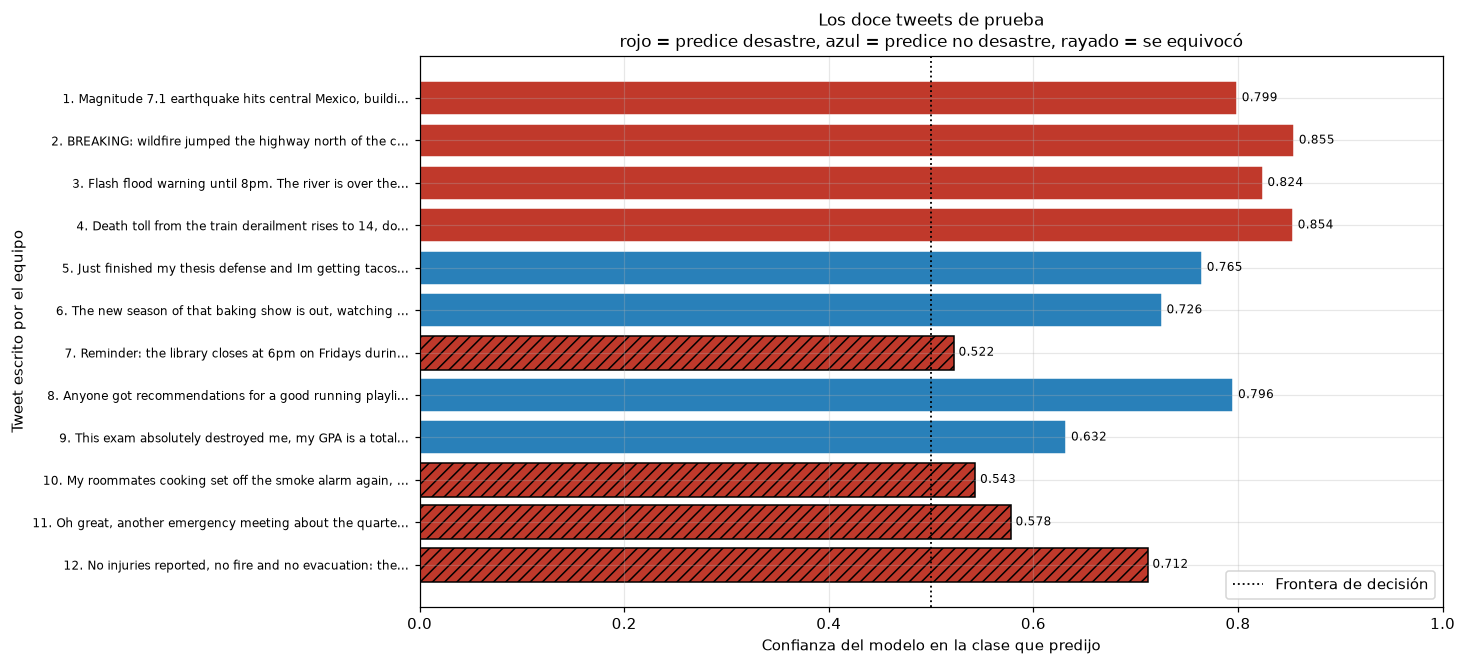

Confianza media cuando acierta:      0.781
Confianza media cuando se equivoca:  0.589


In [4]:
fig, ax = plt.subplots(figsize=(config.FIG_ANCHO + 2, config.FIG_ALTO + 1.5))

orden = prueba.iloc[::-1]
colores = [config.COLOR_DESASTRE if p == 'desastre' else config.COLOR_NO_DESASTRE
           for p in orden.prediccion]
barras = ax.barh([f'{n}. {t[:52]}...' for n, t in zip(orden.n, orden.texto_original)],
                 orden.confianza, color=colores, edgecolor='white')

for barra, acierto in zip(barras, orden.acierto):
    if not acierto:
        barra.set_hatch('///')
        barra.set_edgecolor('black')

ax.bar_label(barras, fmt='%.3f', padding=3, fontsize=8)
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.2,
           label='Frontera de decisión')
ax.set_xlim(0, 1.0)
ax.set_xlabel('Confianza del modelo en la clase que predijo')
ax.set_ylabel('Tweet escrito por el equipo')
ax.set_title('Los doce tweets de prueba\n'
             'rojo = predice desastre, azul = predice no desastre, rayado = se equivocó',
             fontsize=11)
ax.tick_params(axis='y', labelsize=8)
ax.legend(loc='lower right')
guardar(fig, 'clasificador_12_tweets.png')
plt.show()

print(f'Confianza media cuando acierta:      {prueba[prueba.acierto].confianza.mean():.3f}')
print(f'Confianza media cuando se equivoca:  {prueba[~prueba.acierto].confianza.mean():.3f}')

## Por qué falló donde falló

Con un modelo lineal se puede reconstruir la decisión exacta: la contribución de cada término
es su valor TF-IDF multiplicado por su coeficiente, y la suma de todas más el intercepto es lo
que decide la clase. No hay que suponer nada sobre por qué se equivocó; se puede leer.

In [5]:
modelo = cargar_modelo()
vectorizador = modelo.named_steps['vec']
clasificador = modelo.named_steps['clf']
nombres = np.array(vectorizador.get_feature_names_out())
intercepto = float(clasificador.intercept_[0])


def descomponer(texto_procesado, n=5):
    x = vectorizador.transform([texto_procesado]).toarray()[0]
    contribucion = x * clasificador.coef_[0]
    orden = np.argsort(contribucion)
    hacia_desastre = [(nombres[i], contribucion[i]) for i in orden[::-1][:n]
                      if contribucion[i] > 0]
    hacia_no = [(nombres[i], contribucion[i]) for i in orden[:n] if contribucion[i] < 0]
    return hacia_desastre, hacia_no, contribucion.sum() + intercepto


filas_descomposicion = []
for _, f in prueba[~prueba.acierto].iterrows():
    hacia_desastre, hacia_no, total = descomponer(f.texto_procesado)
    print(f'{f.n}. {f.texto_original[:88]}')
    print(f'   predijo "{f.prediccion}" con confianza {f.confianza:.3f}   '
          f'(suma de contribuciones + intercepto = {total:+.3f})')
    print(f'   empuja a DESASTRE:     '
          f"{', '.join(f'{t} {c:+.3f}' for t, c in hacia_desastre)}")
    print(f'   empuja a NO DESASTRE:  '
          f"{', '.join(f'{t} {c:+.3f}' for t, c in hacia_no) or '(ninguno)'}")
    print()
    for termino, contribucion in hacia_desastre:
        filas_descomposicion.append({'n': f.n, 'tweet': f.texto_original[:80],
                                     'termino': termino, 'contribucion': contribucion,
                                     'empuja_hacia': 'desastre'})
    for termino, contribucion in hacia_no:
        filas_descomposicion.append({'n': f.n, 'tweet': f.texto_original[:80],
                                     'termino': termino, 'contribucion': contribucion,
                                     'empuja_hacia': 'no desastre'})

print(f'Intercepto del modelo: {intercepto:+.3f} '
      f'(el sesgo de partida hacia la clase mayoritaria)')
guardar_tabla(pd.DataFrame(filas_descomposicion), 'clasificador_descomposicion_errores.csv')

7. Reminder: the library closes at 6pm on Fridays during the summer break
   predijo "desastre" con confianza 0.522   (suma de contribuciones + intercepto = +0.090)
   empuja a DESASTRE:     close +0.233, reminder +0.180, friday +0.116, library +0.026, break +0.018
   empuja a NO DESASTRE:  summer -0.078

10. My roommates cooking set off the smoke alarm again, the whole apartment is on fire lol
   predijo "desastre" con confianza 0.543   (suma de contribuciones + intercepto = +0.174)
   empuja a DESASTRE:     fire +0.897, alarm +0.242, set +0.226, apartment +0.069
   empuja a NO DESASTRE:  lol -0.475, smoke -0.360, whole -0.021

11. Oh great, another emergency meeting about the quarterly report. Were all going to die of
   predijo "desastre" con confianza 0.578   (suma de contribuciones + intercepto = +0.315)
   empuja a DESASTRE:     report +0.479, another +0.214, emergency +0.115, meeting +0.099, oh +0.095
   empuja a NO DESASTRE:  great -0.178, going -0.138, going die -0.046

12. No

**Interpretación de los cuatro fallos.** El modelo acierta 8 de 12, y los cuatro fallos
cuentan una historia coherente.

**Tweet 12, la negación — el fallo más instructivo.** *"No injuries reported, no fire and no
evacuation: the alarm at the plant turned out to be false"* es un tweet que **niega** un
desastre, y el modelo lo clasifica como desastre con 0.712 de confianza. Los términos que lo
empujan son `fire` (+0.565), `evacuation` (+0.357) y `reported` (+0.202): las palabras están
ahí, y la bolsa de palabras no representa que vayan precedidas de `no`.

El detalle fino es mejor todavía. El preprocesamiento **conserva las negaciones a propósito**
—se excluyeron del listado de palabras vacías—, así que `no` sí llega al modelo, e incluso se
forma el bigrama `no injury`. Pero ese bigrama contribuye **+0.103 hacia desastre**, no en
contra. La razón es que los reportes de desastres reales dicen exactamente eso: *"no injuries
reported"* aparece en el corpus dentro de noticias de accidentes. El bigrama aprendió a ser un
indicador de desastre. Conservar la negación era necesario, pero no es suficiente: **el
problema de la negación no se arregla con n-gramas**, y esa es una limitación del enfoque, no
un parámetro por ajustar.

**Tweet 10, contexto doméstico.** *"the whole apartment is on fire"* falla porque `fire` es
literalmente la palabra con mayor coeficiente del modelo (+3.54). La confianza es baja (0.543),
es decir el modelo duda, pero cae del lado equivocado.

**Tweet 11, sarcasmo.** Falla por una razón distinta y algo cómica: el término que más pesa no
es `emergency` (+0.115) sino `report` (+0.479), porque en el corpus *report* aparece en
reportes de noticias. El modelo no entiende el sarcasmo; ni siquiera llega a esa capa.

**Tweet 7, el falso positivo inesperado.** *"Reminder: the library closes at 6pm on Fridays"* no
es una trampa: es un tweet cotidiano que el modelo clasifica como desastre, aunque por muy poco
(0.522, a dos centésimas de la frontera). El culpable es `close` (+0.233), que en el corpus
aparece en *"road closed"*, *"schools closed"*, *"airport closed"*. Es un aviso útil sobre los
límites del vocabulario: el modelo no conoce el sentido de las palabras, solo su compañía
estadística.

**Lo que el modelo sí resistió.** El tweet 9, *"This exam absolutely destroyed me, my GPA is a
total disaster"*, contiene `disaster` y `destroyed` y aun así se clasifica correctamente como
no desastre. Es la trampa que el modelo esquiva, y muestra que no funciona por simple
coincidencia de palabras clave: los otros términos del tweet (`exam`, `gpa`) pesan lo
suficiente para inclinar la balanza.

## Casos borde

Un tweet vacío, uno que se queda sin contenido tras limpiarlo, uno en otro idioma o un texto
más largo que un tweet son entradas reales, no hipótesis de laboratorio. La función **no lanza
excepciones** en ninguno: devuelve su predicción y añade en `advertencia` el motivo por el que
ese resultado merece desconfianza.

La decisión de no lanzar excepción es deliberada. Obligar a quien llama a envolver cada uso en
un `try` traslada el problema; devolver una predicción silenciosa sería peor. La advertencia
deja el resultado utilizable y honesto a la vez.

In [6]:
BORDE = [
    ('cadena vacía', ''),
    ('None', None),
    ('solo un enlace', 'http://t.co/aBcD123'),
    ('solo menciones y signos', '@alguien @otro ... !!!'),
    ('solo emoticones', ':) :) <3'),
    ('otro idioma', 'El terremoto derribo varios edificios en la ciudad esta manana'),
    ('más largo que un tweet', 'the building is on fire and people need help right now ' * 12),
    ('tweet normal, de control', 'Tornado warning issued for the county until midnight'),
]

filas_borde = []
for descripcion, texto in BORDE:
    r = clasificar_tweet(texto)
    filas_borde.append({
        'caso': descripcion,
        'entrada': (repr(texto)[:45] + '...') if texto and len(str(texto)) > 45 else repr(texto),
        'texto_procesado': r['texto_procesado'][:40],
        'prediccion': r['prediccion'],
        'confianza': r['confianza'],
        'advertencia': r['advertencia'],
    })
    print(f"{descripcion:26s} -> {r['prediccion']:>11}  conf={r['confianza']:.3f}")
    if r['advertencia']:
        print(f"{'':26s}    aviso: {r['advertencia']}")
    print()

tabla_borde = pd.DataFrame(filas_borde)
tabla_borde['tiene_advertencia'] = tabla_borde.advertencia.notna()
guardar_tabla(tabla_borde, 'clasificador_casos_borde.csv')

print(f'Casos que produjeron advertencia: {tabla_borde.tiene_advertencia.sum()} '
      f'de {len(tabla_borde)}')
print('Ninguno lanzó excepción.')

cadena vacía               -> no desastre  conf=0.600
                              aviso: El texto recibido está vacío. La predicción refleja únicamente el sesgo del modelo hacia la clase mayoritaria, no el contenido de ningún tweet.

None                       -> no desastre  conf=0.600
                              aviso: El texto recibido está vacío. La predicción refleja únicamente el sesgo del modelo hacia la clase mayoritaria, no el contenido de ningún tweet.

solo un enlace             ->    desastre  conf=0.865
                              aviso: Después de limpiarlo, el tweet no contiene ninguna palabra propia: solo marcadores de enlace o de emoticón. La predicción se apoya únicamente en ellos y no debe tomarse como una lectura del contenido.

solo menciones y signos    -> no desastre  conf=0.600
                              aviso: El texto quedó vacío después de limpiarlo: era solo menciones, signos o palabras vacías. No queda contenido sobre el que decidir.

solo emoticon

**Interpretación.** Los siete casos borde devuelven una predicción utilizable y seis de ellos
avisan del motivo por el que hay que desconfiar; el séptimo es el tweet de control, que no debe
avisar de nada.

Dos merecen comentario porque no son obvios:

- **"Solo un enlace"** se clasifica como desastre con **0.865 de confianza**, la más alta de
  toda la tabla, y sin una sola palabra de contenido. El motivo es una consecuencia directa de
  una decisión de preprocesamiento del equipo: las URLs no se borran, se sustituyen por el
  token `urlweb`, porque el análisis exploratorio midió que su presencia es el patrón más
  discriminativo del corpus (67.35% en desastre contra 41.73% en el resto). Ese token tiene un
  coeficiente de +2.26 y es lo único que queda del tweet. La decisión sigue siendo correcta en
  promedio, pero en este caso extremo produce una predicción segura sin ninguna evidencia
  textual, y por eso la función lo detecta y lo advierte explícitamente.
- **El texto en español** obtiene un aviso de cobertura: solo 3 de sus 10 palabras están en el
  vocabulario del modelo. El umbral de aviso (40%) no se eligió a ojo: la cobertura mediana de
  los tweets reales del conjunto de prueba es del 83%, y solo el 1.87% queda por debajo de 0.40,
  así que el aviso casi nunca molesta con texto legítimo en inglés.

El corpus de entrenamiento es exclusivamente en inglés y el modelo no tiene forma de saberlo:
sin el aviso, devolvería una predicción con la misma apariencia de normalidad que cualquier
otra.

## Síntesis del ejercicio 7

`clasificar_tweet()` cumple el requisito del enunciado: recibe un tweet **sin preprocesar** y
devuelve si se refiere a un desastre, con la limpieza completa ocurriendo dentro de la función
y el modelo cargado desde disco. Está en `src/clasificador.py`, se importa desde cualquier
programa y se comprobó ejecutándola en un intérprete limpio.

Sobre los 12 tweets escritos por el equipo acierta **8**. Los cuatro fallos no son aleatorios:
tres son las trampas diseñadas contra debilidades conocidas —contexto doméstico, sarcasmo y
negación— y el cuarto es un falso positivo por vocabulario compartido (`close`), decidido a dos
centésimas de la frontera.

El resultado es coherente con lo medido en el ejercicio 6 sobre el conjunto de prueba, y
conviene no leerlo como una métrica: doce tweets elegidos a propósito, un tercio de ellos
adversarios, no estiman el desempeño del modelo. Lo que sí muestran es **de qué se equivoca**,
que era su propósito.